# 03 - Feature Engineering cho bài toán phân cụm việc làm Việt Nam


Mặc định notebook chạy với `SAMPLE_SIZE = 20000` để phát triển và kiểm thử nhanh. Trước khi nộp hoặc xuất artifact cuối trên toàn bộ dữ liệu, đổi `SAMPLE_SIZE = None` rồi chạy lại toàn bộ notebook.

Artifact đầu ra chính:

- `artifacts/features/X_train_features.npz`
- `artifacts/features/X_test_features.npz`
- `artifacts/features/X_train_umap.npy`
- `artifacts/features/X_test_umap.npy`
- `artifacts/features/train_metadata.csv`
- `artifacts/features/test_metadata.csv`
- `artifacts/features/tfidf_model.joblib`
- `artifacts/features/svd_model.joblib`
- `artifacts/features/umap_model.joblib`
- `artifacts/features/feature_pipeline.joblib`


## 0. Cài đặt và imports


In [57]:
%pip install -q pandas numpy scipy matplotlib seaborn scikit-learn joblib umap-learn


Note: you may need to restart the kernel to use updated packages.


In [58]:
from __future__ import annotations

import re
from pathlib import Path

import joblib
import umap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse
from scipy.stats import ks_2samp
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 90)


## 1. Cấu hình đường dẫn và tham số

`SAMPLE_SIZE = 20000` là mặc định để notebook chạy nhanh trong giai đoạn phát triển. Khi cần xuất artifact cuối trên toàn bộ dữ liệu, đổi thành `None` rồi chạy lại từ đầu.


In [59]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CLEAN_DIR = PROJECT_ROOT / "artifacts" / "clean"
FEATURES_DIR = PROJECT_ROOT / "artifacts" / "features"
FIGURES_DIR = PROJECT_ROOT / "artifacts" / "figures" / "feature_engineering"

TRAIN_PATH = CLEAN_DIR / "clean_data_train.csv"
TEST_PATH = CLEAN_DIR / "clean_data_test.csv"

SAMPLE_SIZE = None
RANDOM_STATE = 42
TFIDF_MAX_FEATURES = 30000
MAX_SVD_COMPONENTS = 300
DROP_FIRST_SVD_COMPONENT_FOR_UMAP = True
EVALUATION_CLUSTER_K = 8
EVALUATION_SAMPLE_SIZE = 5000
TSNE_SAMPLE_SIZE = 5000

FEATURES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Train path:", TRAIN_PATH)
print("Test path:", TEST_PATH)
print("Features dir:", FEATURES_DIR)
print("Figures dir:", FIGURES_DIR)


Project root: d:\02. DUT\04. Khoa học dữ liệu\final-data-science
Train path: d:\02. DUT\04. Khoa học dữ liệu\final-data-science\artifacts\clean\clean_data_train.csv
Test path: d:\02. DUT\04. Khoa học dữ liệu\final-data-science\artifacts\clean\clean_data_test.csv
Features dir: d:\02. DUT\04. Khoa học dữ liệu\final-data-science\artifacts\features
Figures dir: d:\02. DUT\04. Khoa học dữ liệu\final-data-science\artifacts\figures\feature_engineering


## 2. Helper functions


In [60]:
VIETNAMESE_STOPWORDS = [
    "rat",
    "su",
    "moi",
    "lam",
    "de",
    "neu",
    "nen",
    "dang",
    "da",
    "se",
    "tai",
    "qua",
    "ve",
    "hoac",
    "theo",
    "nhu",
    "cung",
    "nhieu",
    "den",
    "tu",
    "khac",
    "dam bao",
    "thuc hien",
    "khong",
    "cho",
    "khi",
    "nhung",
    "trong",
    "voi",
    "duoc",
    "cua",
    "cac",
    "co",
    "va",
    "cong viec",
    "chi tiet",
    "trao doi",
    "phong van",
    "che do",
    "day du",
    "tham gia",
    "bao hiem",
    "moi truong",
    "nang dong",
    "than thien",
    "chuyen nghiep",
    "trach nhiem",
    "nhanh nhen",
    "ky nang",
    "yeu cau",
    "kinh nghiem",
    "ung vien",
    "tot",
    "quyen loi",
    "huong",
    "luong",
    "thuong",
    "co hoi",
    "phat trien",
    "cong ty",
    "quy dinh",
    "nhan vien",
    "khach hang",
    "lien he",
    "ho tro",
    "lam viec"
]

def tokenize_stopword_phrases(stopwords: list[str]) -> list[str]:
    token_pattern = re.compile(r"(?u)\b\w\w+\b")
    tokens = set()
    for word in stopwords:
        tokens.update(token_pattern.findall(word.lower()))
    return sorted(tokens)


TOKENIZED_VIETNAMESE_STOPWORDS = tokenize_stopword_phrases(VIETNAMESE_STOPWORDS)

TEXT_COLUMNS_FOR_CLUSTERING = [
    "job_title",
    "job_description",
    "requirements",
    "benefits",
]

# Categorical variables are metadata only: use them for EDA, external validation,
# visualization color, and cluster profiling. They must not enter the clustering
# feature matrix, otherwise the unsupervised task leaks the labels we want to inspect.
CATEGORICAL_METADATA_COLUMNS = [
    "job_type",
    "job_industry",
    "experience_level",
    "education_level",
    "job_position",
    "location_simplified",
]

BASE_NUMERIC_COLUMNS = [
    "salary_expected_million_vnd",
    "salary_range_width",
    "salary_min",
    "salary_max",
    "is_salary_outlier",
]

TEXT_LENGTH_COLUMNS = [
    "job_description_length",
    "requirements_length",
    "benefits_length",
    "final_text_length",
]

# Numeric columns are kept for EDA/profile only. They are intentionally excluded from
# the clustering feature matrix to avoid salary or document-length dominated components.
NUMERIC_COLUMNS = []

METADATA_COLUMNS = [
    "id",
    "job_title",
    "company_name",
    "location",
    "location_simplified",
    "job_industry",
    "job_type",
    "experience_level",
    "education_level",
    "job_position",
    "salary_expected_million_vnd",
    "salary_range_width",
    "salary_min",
    "salary_max",
    "is_salary_outlier",
    "final_text",
]


def save_plot(fig: plt.Figure, filename: str) -> None:
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=200, bbox_inches="tight")
    display(fig)
    plt.close(fig)


def load_clean_data(sample_size: int | None = None) -> tuple[pd.DataFrame, pd.DataFrame]:
    train = pd.read_csv(TRAIN_PATH, nrows=sample_size)
    test = pd.read_csv(TEST_PATH, nrows=max(1, sample_size // 10) if sample_size else None)
    return train, test


def schema_summary(df: pd.DataFrame, split: str) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "split": split,
            "column": df.columns,
            "dtype": [str(dtype) for dtype in df.dtypes],
            "missing_count": [int(df[col].isna().sum()) for col in df.columns],
            "missing_ratio": [float(df[col].isna().mean()) for col in df.columns],
            "n_unique": [int(df[col].nunique(dropna=True)) for col in df.columns],
        }
    )


def simplify_location(value: object) -> str:
    text = "" if pd.isna(value) else str(value).lower()
    patterns = [
        ("ho chi minh", ["ho chi minh", "ho chi minh", "tp.ho chi minh", "tphcm", "hcm", "sai gon", "sai gon"]),
        ("ha noi", ["ha noi", "ha noi", "hn"]),
        ("da nang", ["da nang", "da nang"]),
        ("binh duong", ["binh duong", "binh duong"]),
        ("dong nai", ["dong nai", "dong nai"]),
        ("hai phong", ["hai phong", "hai phong"]),
        ("can tho", ["can tho", "can tho"]),
        ("bac ninh", ["bac ninh", "bac ninh"]),
    ]
    for label, keywords in patterns:
        if any(keyword in text for keyword in keywords):
            return label
    if text.strip() in {"", "unknown", "khong", "khong"}:
        return "unknown"
    return "other"


def make_final_text(df: pd.DataFrame) -> pd.Series:
    parts = []
    for column in TEXT_COLUMNS_FOR_CLUSTERING:
        value = df[column].fillna("").astype(str)
        # Give the job title a small boost because it is concise and highly semantic,
        # but keep label/metadata fields out of the text representation.
        if column == "job_title":
            value = value + " " + value
        parts.append(value)
    return pd.concat(parts, axis=1).agg(" ".join, axis=1).str.replace(r"\s+", " ", regex=True).str.strip()


def add_engineered_columns(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    result["location_simplified"] = result["location"].map(simplify_location)
    result["final_text"] = make_final_text(result)
    result["log_salary_expected"] = np.log1p(result["salary_expected_million_vnd"].clip(lower=0))
    result["log_salary_range_width"] = np.log1p(result["salary_range_width"].clip(lower=0))
    result["job_description_length"] = result["job_description"].fillna("").astype(str).str.len()
    result["requirements_length"] = result["requirements"].fillna("").astype(str).str.len()
    result["benefits_length"] = result["benefits"].fillna("").astype(str).str.len()
    result["final_text_length"] = result["final_text"].str.len()
    result["is_salary_outlier"] = result["is_salary_outlier"].astype(int)
    return result


def top_category_shift(train: pd.DataFrame, test: pd.DataFrame, column: str, top_n: int = 12) -> pd.DataFrame:
    top_values = train[column].fillna("unknown").astype(str).value_counts().head(top_n).index
    train_ratio = train[column].fillna("unknown").astype(str).value_counts(normalize=True)
    test_ratio = test[column].fillna("unknown").astype(str).value_counts(normalize=True)
    rows = []
    for value in top_values:
        rows.append(
            {
                "column": column,
                "value": value,
                "train_ratio": float(train_ratio.get(value, 0.0)),
                "test_ratio": float(test_ratio.get(value, 0.0)),
                "abs_diff": float(abs(train_ratio.get(value, 0.0) - test_ratio.get(value, 0.0))),
            }
        )
    return pd.DataFrame(rows)


def plot_top_categories(df: pd.DataFrame, column: str, filename: str, top_n: int = 12) -> None:
    fig, ax = plt.subplots(figsize=(10, 6))
    df[column].fillna("unknown").astype(str).value_counts().head(top_n).sort_values().plot.barh(ax=ax, color="#4c78a8")
    ax.set_title(f"Top {top_n} {column}")
    ax.set_xlabel("count")
    save_plot(fig, filename)


def plot_distribution_shift(train: pd.DataFrame, test: pd.DataFrame, column: str, filename: str, clip_quantile: float | None = None) -> None:
    train_values = train[column].dropna()
    test_values = test[column].dropna()
    if clip_quantile is not None:
        upper = train_values.quantile(clip_quantile)
        train_values = train_values.clip(upper=upper)
        test_values = test_values.clip(upper=upper)
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.kdeplot(train_values, ax=ax, label="train", fill=False)
    sns.kdeplot(test_values, ax=ax, label="test", fill=False)
    ax.set_title(f"Train/Test distribution shift: {column}")
    ax.legend()
    save_plot(fig, filename)


## 3. Load và validate dữ liệu sạch


In [61]:
train_df, test_df = load_clean_data(SAMPLE_SIZE)

raw_metadata_required_columns = [column for column in CATEGORICAL_METADATA_COLUMNS if column != "location_simplified"]
required_columns = set(TEXT_COLUMNS_FOR_CLUSTERING + raw_metadata_required_columns + BASE_NUMERIC_COLUMNS + ["id", "company_name", "salary_parse_status"])
missing_train_columns = sorted(required_columns - set(train_df.columns))
missing_test_columns = sorted(required_columns - set(test_df.columns))
assert not missing_train_columns, f"Train missing columns: {missing_train_columns}"
assert not missing_test_columns, f"Test missing columns: {missing_test_columns}"
assert list(train_df.columns) == list(test_df.columns), "Train/test schema mismatch"
assert set(train_df["id"]).isdisjoint(set(test_df["id"])), "Train/test id overlap detected"
assert train_df["id"].duplicated().sum() == 0, "Duplicate id in train"
assert test_df["id"].duplicated().sum() == 0, "Duplicate id in test"
assert (train_df["salary_parse_status"] == "valid").all(), "Train contains invalid salary rows"
assert (test_df["salary_parse_status"] == "valid").all(), "Test contains invalid salary rows"
assert (train_df["salary_expected_million_vnd"] > 0).all(), "Train contains non-positive salary"
assert (test_df["salary_expected_million_vnd"] > 0).all(), "Test contains non-positive salary"

ratio_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(train_df), "ratio": len(train_df) / (len(train_df) + len(test_df))},
        {"split": "test", "rows": len(test_df), "ratio": len(test_df) / (len(train_df) + len(test_df))},
    ]
)
display(ratio_summary)
display(pd.concat([schema_summary(train_df, "train"), schema_summary(test_df, "test")], ignore_index=True))


,split,rows,ratio
0,train,529109,0.9
1,test,58790,0.1


,split,column,dtype,missing_count,missing_ratio,n_unique
0,train,id,int64,0,0.000000,529109
1,train,job_title,str,0,0.000000,261228
2,train,company_name,str,0,0.000000,100912
3,train,salary,str,0,0.000000,4745
4,train,location,str,0,0.000000,227297
5,train,job_type,str,0,0.000000,19
6,train,job_industry,str,0,0.000000,3504
7,train,experience_level,str,0,0.000000,99
8,train,education_level,str,0,0.000000,10
9,train,job_position,str,0,0.000000,54


## 4. EDA dữ liệu sạch


In [62]:
train_df = add_engineered_columns(train_df)
test_df = add_engineered_columns(test_df)

numeric_eda = train_df[["salary_expected_million_vnd", "salary_range_width", "salary_min", "salary_max", *TEXT_LENGTH_COLUMNS]].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
categorical_eda = pd.DataFrame(
    [
        {
            "column": column,
            "n_unique_train": train_df[column].nunique(dropna=True),
            "n_unique_test": test_df[column].nunique(dropna=True),
            "top_train_value": train_df[column].fillna("unknown").astype(str).mode().iloc[0],
        }
        for column in CATEGORICAL_METADATA_COLUMNS
    ]
)

display(numeric_eda)
display(categorical_eda)

numeric_eda.to_csv(FEATURES_DIR / "clean_numeric_eda_summary.csv")
categorical_eda.to_csv(FEATURES_DIR / "clean_categorical_eda_summary.csv", index=False)


,count,mean,std,min,1%,25%,50%,75%,99%,max
salary_expected_million_vnd,529109.0,13.706971,12.173076,0.000018,2.5,9.0,12.0,15.0,40.0,998.5
salary_range_width,529109.0,7.420316,15.123285,0.000000,0.5,3.0,5.0,8.0,44.0,998.0
salary_min,529109.0,9.996813,8.061278,0.000000,1.0,7.0,9.0,12.0,30.0,998.0
salary_max,529109.0,17.417129,18.594091,0.000025,3.0,10.0,15.0,20.0,50.0,999.0
job_description_length,529109.0,579.361672,448.597881,1.000000,105.0,297.0,468.0,722.0,2276.0,22011.0
requirements_length,529109.0,317.567556,219.165810,1.000000,19.0,171.0,278.0,412.0,1067.0,6497.0
benefits_length,529109.0,378.196440,247.350561,1.000000,93.0,219.0,324.0,468.0,1395.0,32857.0
final_text_length,529109.0,1350.802305,652.380195,25.000000,362.0,918.0,1237.0,1648.0,3478.0,45105.0


,column,n_unique_train,n_unique_test,top_train_value
0,job_type,19,13,toàn thời gian
1,job_industry,3504,844,bán hàng - kinh doanh
2,experience_level,99,59,3 năm
3,education_level,10,9,không
4,job_position,54,31,nhân viên
5,location_simplified,10,10,other


### 4.1. Biểu đồ tổng quan cho dữ liệu sạch

Các biểu đồ dưới đây mô tả schema, missing value, kích thước train/test, phân phối lương, độ dài văn bản và các biến phân loại chính được dùng trong pipeline phân cụm.


,split,rows,features_per_sample,missing_cells,missing_cell_ratio,salary_outlier_ratio
0,train,529109,34,490882,0.027287,0.072248
1,test,58790,34,54577,0.027304,0.071662


,column,dtype,missing_count,missing_ratio,n_unique
0,id,int64,0,0.000000,529109
1,job_title,str,0,0.000000,261228
2,company_name,str,0,0.000000,100912
3,salary,str,0,0.000000,4745
4,location,str,0,0.000000,227297
5,job_type,str,0,0.000000,19
6,job_industry,str,0,0.000000,3504
7,experience_level,str,0,0.000000,99
8,education_level,str,0,0.000000,10
9,job_position,str,0,0.000000,54


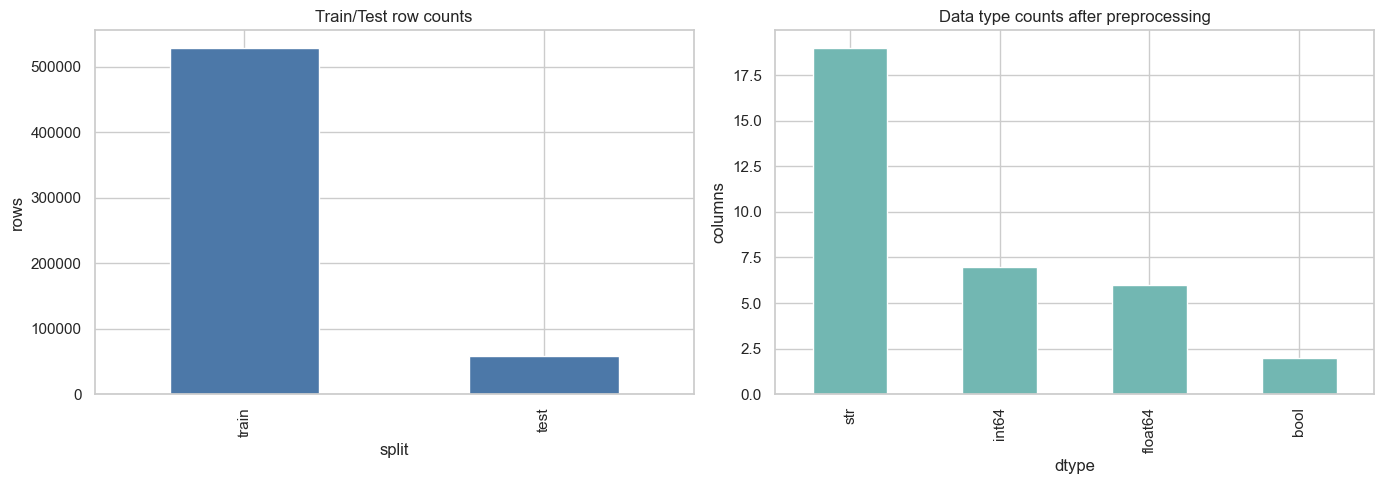

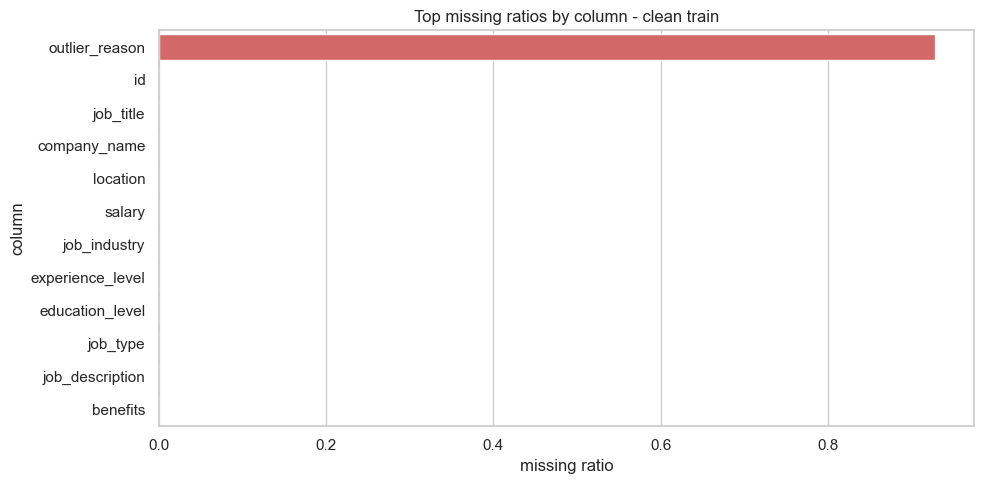

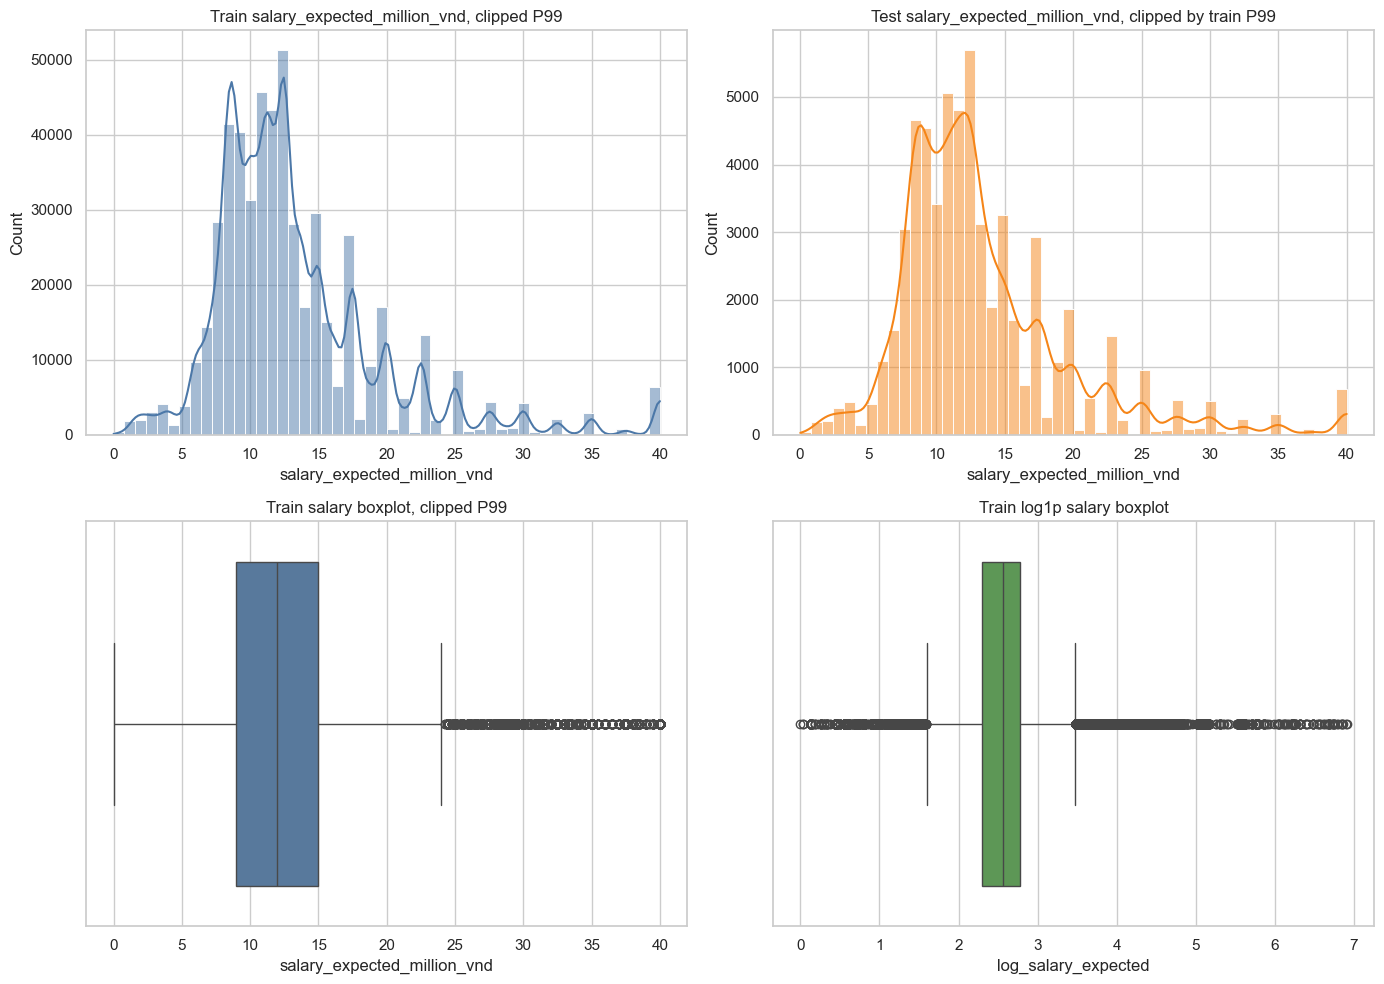

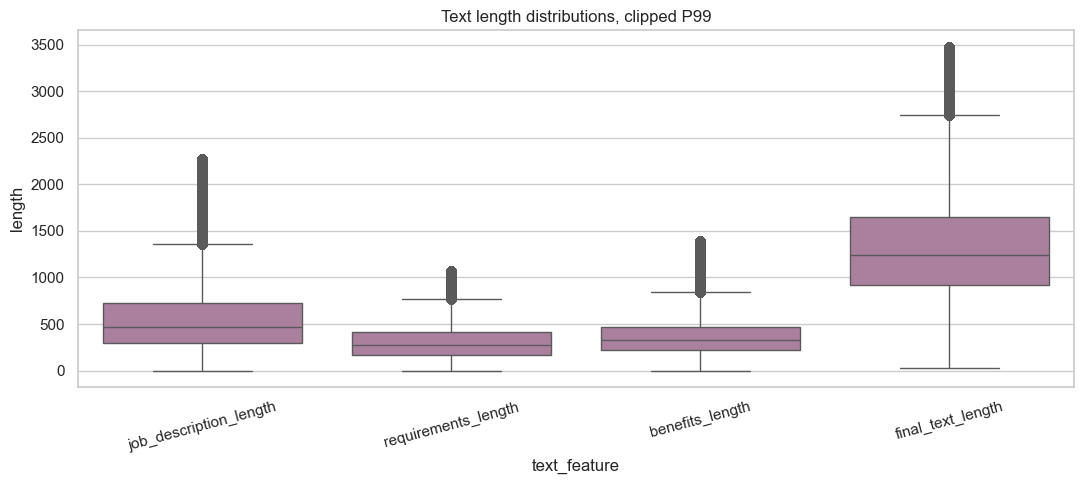

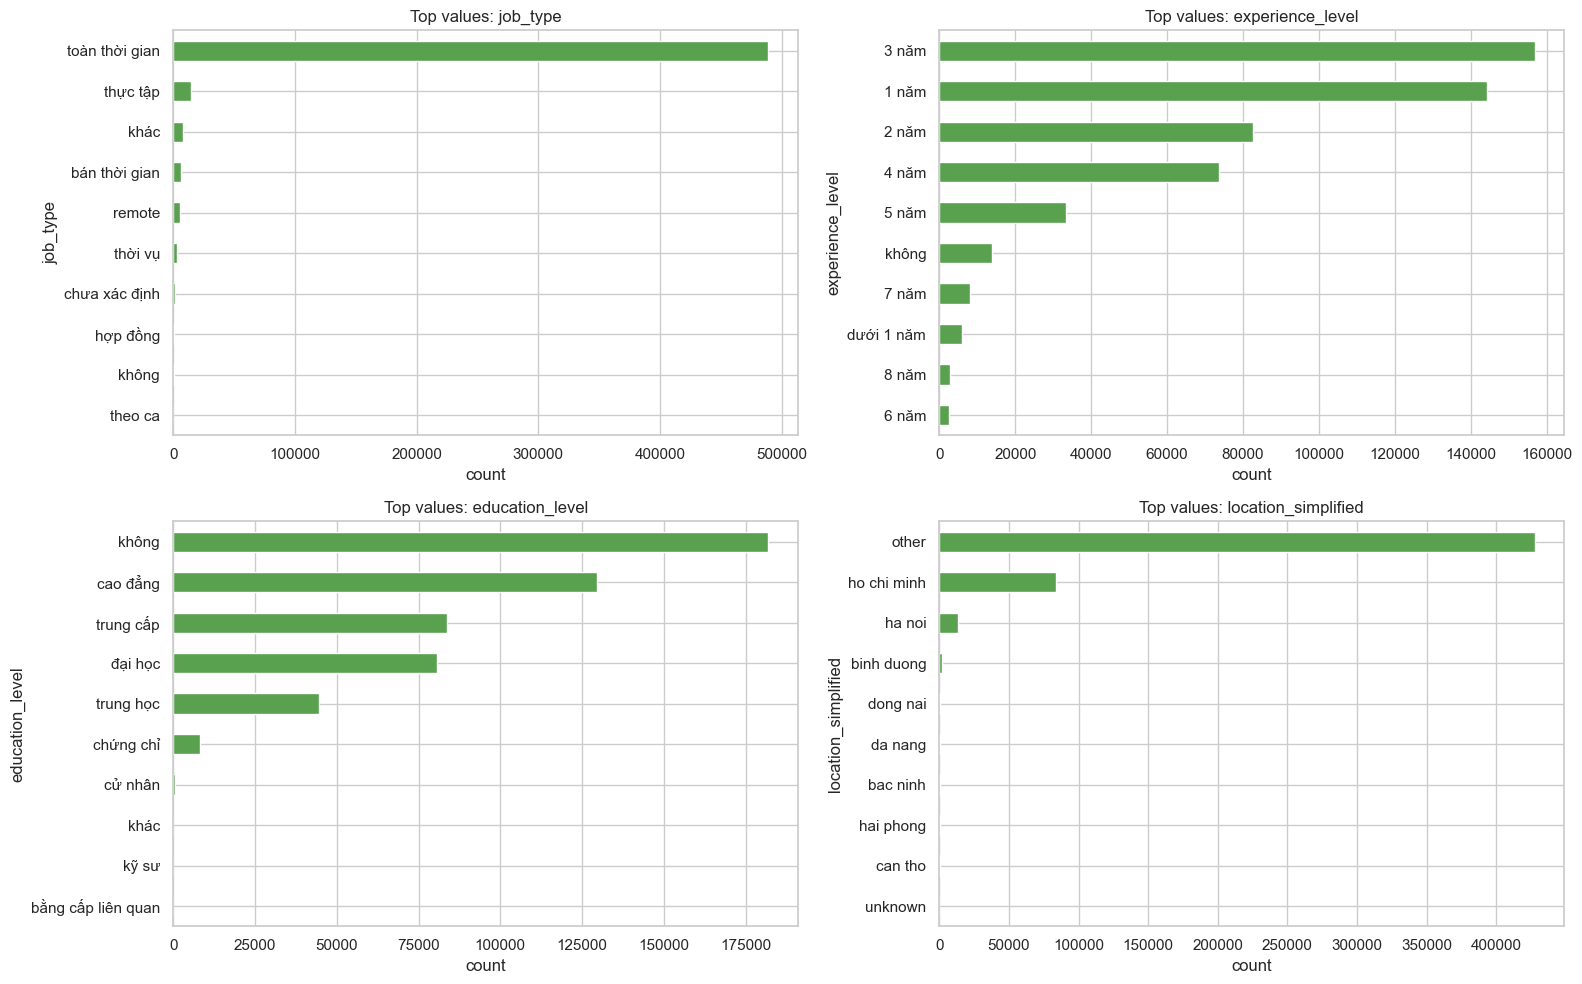

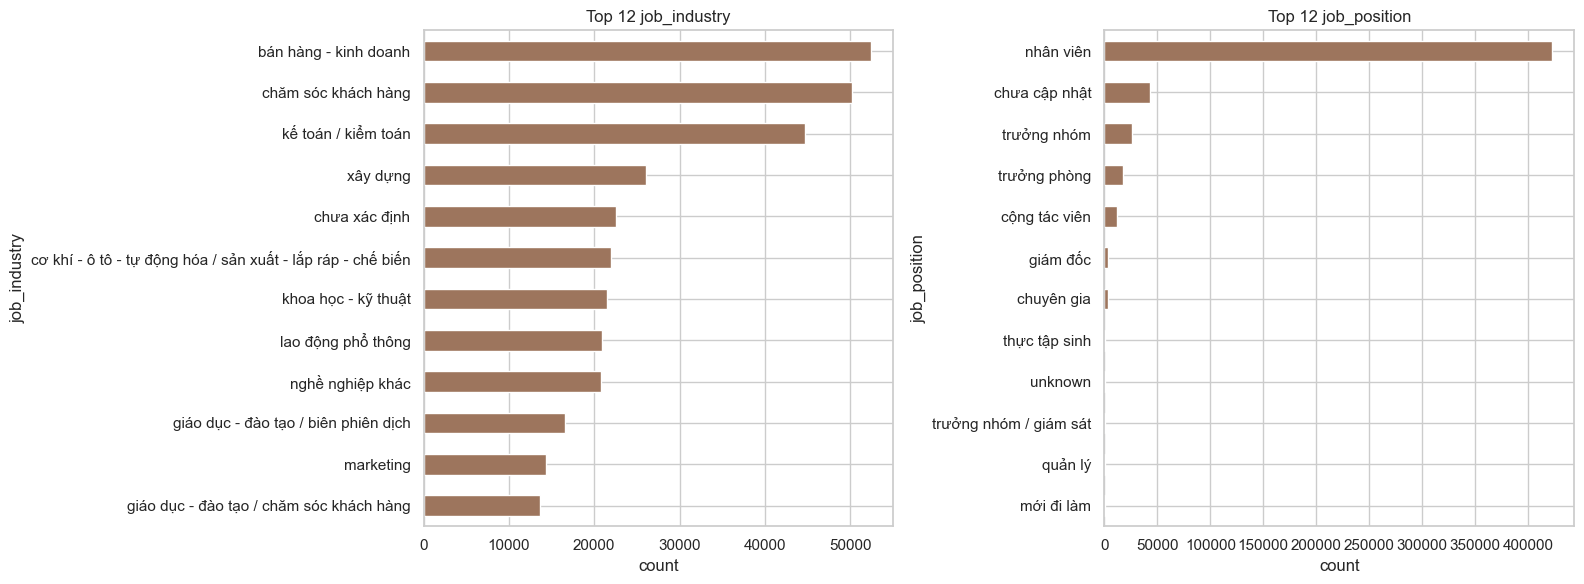

In [63]:
# Bảng tổng quan số mẫu, số đặc trưng, missing và outlier
dataset_overview = pd.DataFrame([
    {
        "split": "train",
        "rows": len(train_df),
        "features_per_sample": train_df.shape[1],
        "missing_cells": int(train_df.isna().sum().sum()),
        "missing_cell_ratio": float(train_df.isna().sum().sum() / train_df.size),
        "salary_outlier_ratio": float(train_df["is_salary_outlier"].mean()),
    },
    {
        "split": "test",
        "rows": len(test_df),
        "features_per_sample": test_df.shape[1],
        "missing_cells": int(test_df.isna().sum().sum()),
        "missing_cell_ratio": float(test_df.isna().sum().sum() / test_df.size),
        "salary_outlier_ratio": float(test_df["is_salary_outlier"].mean()),
    },
])
display(dataset_overview)
dataset_overview.to_csv(FEATURES_DIR / "dataset_overview_after_preprocessing.csv", index=False)

# Kiểu dữ liệu và missing value theo cột
schema_train = schema_summary(train_df, "train")
display(schema_train[["column", "dtype", "missing_count", "missing_ratio", "n_unique"]])
schema_train.to_csv(FEATURES_DIR / "schema_summary_after_preprocessing.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dataset_overview.plot.bar(x="split", y="rows", ax=axes[0], legend=False, color="#4c78a8")
axes[0].set_title("Train/Test row counts")
axes[0].set_ylabel("rows")
train_df.dtypes.astype(str).value_counts().plot.bar(ax=axes[1], color="#72b7b2")
axes[1].set_title("Data type counts after preprocessing")
axes[1].set_xlabel("dtype")
axes[1].set_ylabel("columns")
save_plot(fig, "eda_overview_rows_and_dtypes.png")

missing_plot = schema_train.sort_values("missing_ratio", ascending=False).head(12)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=missing_plot, x="missing_ratio", y="column", ax=ax, color="#e45756")
ax.set_title("Top missing ratios by column - clean train")
ax.set_xlabel("missing ratio")
save_plot(fig, "eda_missing_ratio_top_columns.png")

# Phân phối biến lương quan trọng dùng để profiling, không phải target supervised
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
salary_upper = train_df["salary_expected_million_vnd"].quantile(0.99)
sns.histplot(train_df["salary_expected_million_vnd"].clip(upper=salary_upper), bins=50, kde=True, ax=axes[0, 0], color="#4c78a8")
axes[0, 0].set_title("Train salary_expected_million_vnd, clipped P99")
sns.histplot(test_df["salary_expected_million_vnd"].clip(upper=salary_upper), bins=50, kde=True, ax=axes[0, 1], color="#f58518")
axes[0, 1].set_title("Test salary_expected_million_vnd, clipped by train P99")
sns.boxplot(x=train_df["salary_expected_million_vnd"].clip(upper=salary_upper), ax=axes[1, 0], color="#4c78a8")
axes[1, 0].set_title("Train salary boxplot, clipped P99")
sns.boxplot(x=train_df["log_salary_expected"], ax=axes[1, 1], color="#54a24b")
axes[1, 1].set_title("Train log1p salary boxplot")
save_plot(fig, "eda_salary_distribution_and_boxplot.png")

# Text length distributions
length_melt = train_df[["job_description_length", "requirements_length", "benefits_length", "final_text_length"]].clip(
    upper=train_df[["job_description_length", "requirements_length", "benefits_length", "final_text_length"]].quantile(0.99),
    axis=1,
).melt(var_name="text_feature", value_name="length")
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=length_melt, x="text_feature", y="length", ax=ax, color="#b279a2")
ax.set_title("Text length distributions, clipped P99")
ax.tick_params(axis="x", rotation=15)
save_plot(fig, "eda_text_length_boxplot.png")

# Các biến categorical quan trọng chỉ dùng để EDA/profile, không đưa vào feature matrix
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, column in zip(axes.ravel(), ["job_type", "experience_level", "education_level", "location_simplified"]):
    train_df[column].fillna("unknown").astype(str).value_counts().head(10).sort_values().plot.barh(ax=ax, color="#59a14f")
    ax.set_title(f"Top values: {column}")
    ax.set_xlabel("count")
save_plot(fig, "eda_core_categorical_distributions.png")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, column in zip(axes, ["job_industry", "job_position"]):
    train_df[column].fillna("unknown").astype(str).value_counts().head(12).sort_values().plot.barh(ax=ax, color="#9d755d")
    ax.set_title(f"Top 12 {column}")
    ax.set_xlabel("count")
save_plot(fig, "eda_industry_position_distributions.png")


### Nhận xét EDA
- **Salary**: Phân phối lệch phải và có outlier rõ. Trong notebook này salary chỉ dùng để EDA và profile cụm sau này, không đưa vào feature matrix để tránh cụm bị chi phối bởi thang đo lương.
- **Text**: `job_title`, `job_description`, `requirements`, `benefits` là nguồn tín hiệu chính cho bài toán phân cụm. Độ dài văn bản biến động lớn, nên TF-IDF kết hợp `sublinear_tf`, `max_df`, stopwords và SVD để giảm ảnh hưởng của các từ/cấu trúc quá phổ biến.
- **Metadata categorical**: `job_industry`, `experience_level`, `job_type`, `education_level`, `job_position`, `location_simplified` hữu ích để hiểu dữ liệu, kiểm tra train/test shift, tô màu biểu đồ và profile cụm. Các cột này không được đưa vào feature matrix clustering để tránh rò rỉ nhãn hoặc ép cụm theo metadata có sẵn.


### 4.2. Khám phá tần suất từ vựng (Text EDA)
Phân tích Unigram giúp phát hiện các từ 'rác' (như yêu cầu, kỹ năng, môi trường) để đưa vào danh sách Stopwords. N-gram (Bigram/Trigram) giúp phát hiện các cụm từ đặc trưng ngành nghề.


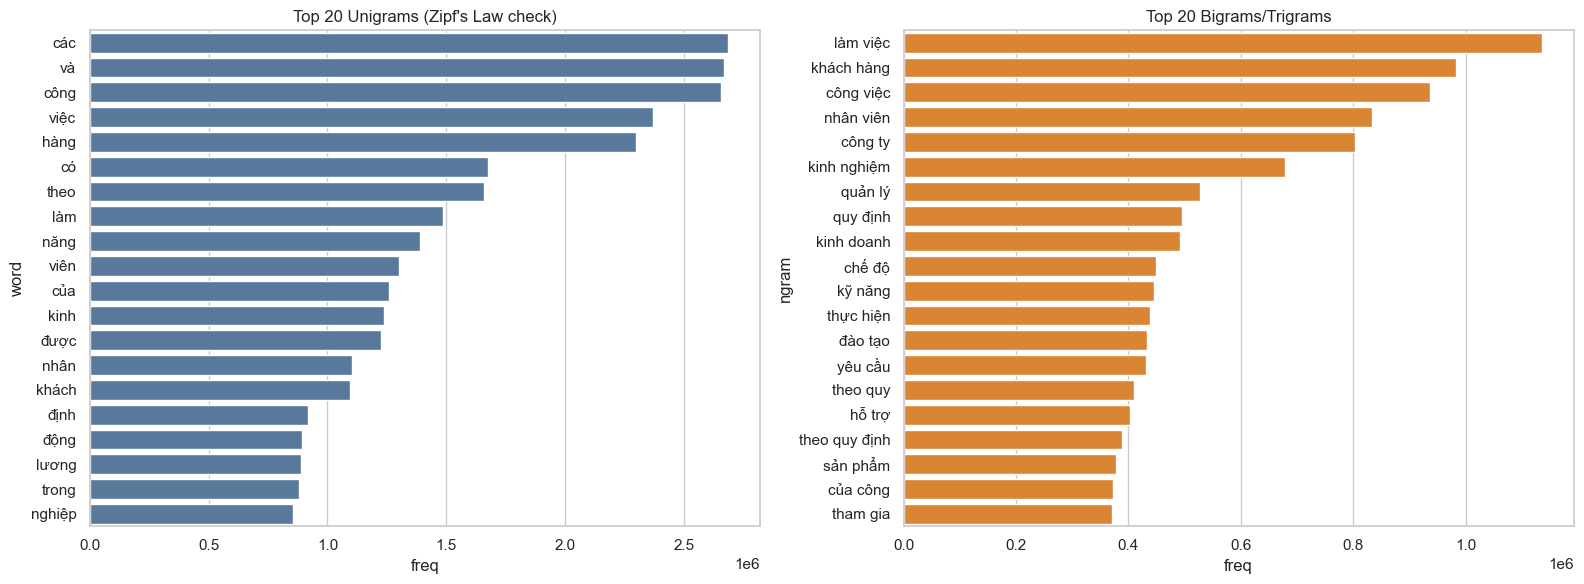

In [64]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# Unigram frequency
vec_1 = CountVectorizer(max_features=20)
counts_1 = vec_1.fit_transform(train_df['final_text'].fillna(''))
words_1 = vec_1.get_feature_names_out()
freqs_1 = counts_1.sum(axis=0).A1
unigram_df = pd.DataFrame({'word': words_1, 'freq': freqs_1}).sort_values('freq', ascending=False)

# Bigram/Trigram frequency
vec_n = CountVectorizer(ngram_range=(2, 3), max_features=20)
counts_n = vec_n.fit_transform(train_df['final_text'].fillna(''))
words_n = vec_n.get_feature_names_out()
freqs_n = counts_n.sum(axis=0).A1
ngram_df = pd.DataFrame({'ngram': words_n, 'freq': freqs_n}).sort_values('freq', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=unigram_df, y='word', x='freq', ax=axes[0], color='#4c78a8')
axes[0].set_title('Top 20 Unigrams (Zipf\'s Law check)')
sns.barplot(data=ngram_df, y='ngram', x='freq', ax=axes[1], color='#f58518')
axes[1].set_title('Top 20 Bigrams/Trigrams')
plt.tight_layout()
save_plot(fig, 'text_frequency_eda.png')


### 4.3. Boxplot phân phối các biến quan trọng
Boxplot bổ sung cho histogram để thấy median, IQR và outlier của salary/text length theo nhóm `experience_level` và `job_industry`. Các biểu đồ này chỉ phục vụ EDA và giải thích dữ liệu; salary, text length và metadata nhóm vẫn không đi vào feature matrix clustering.


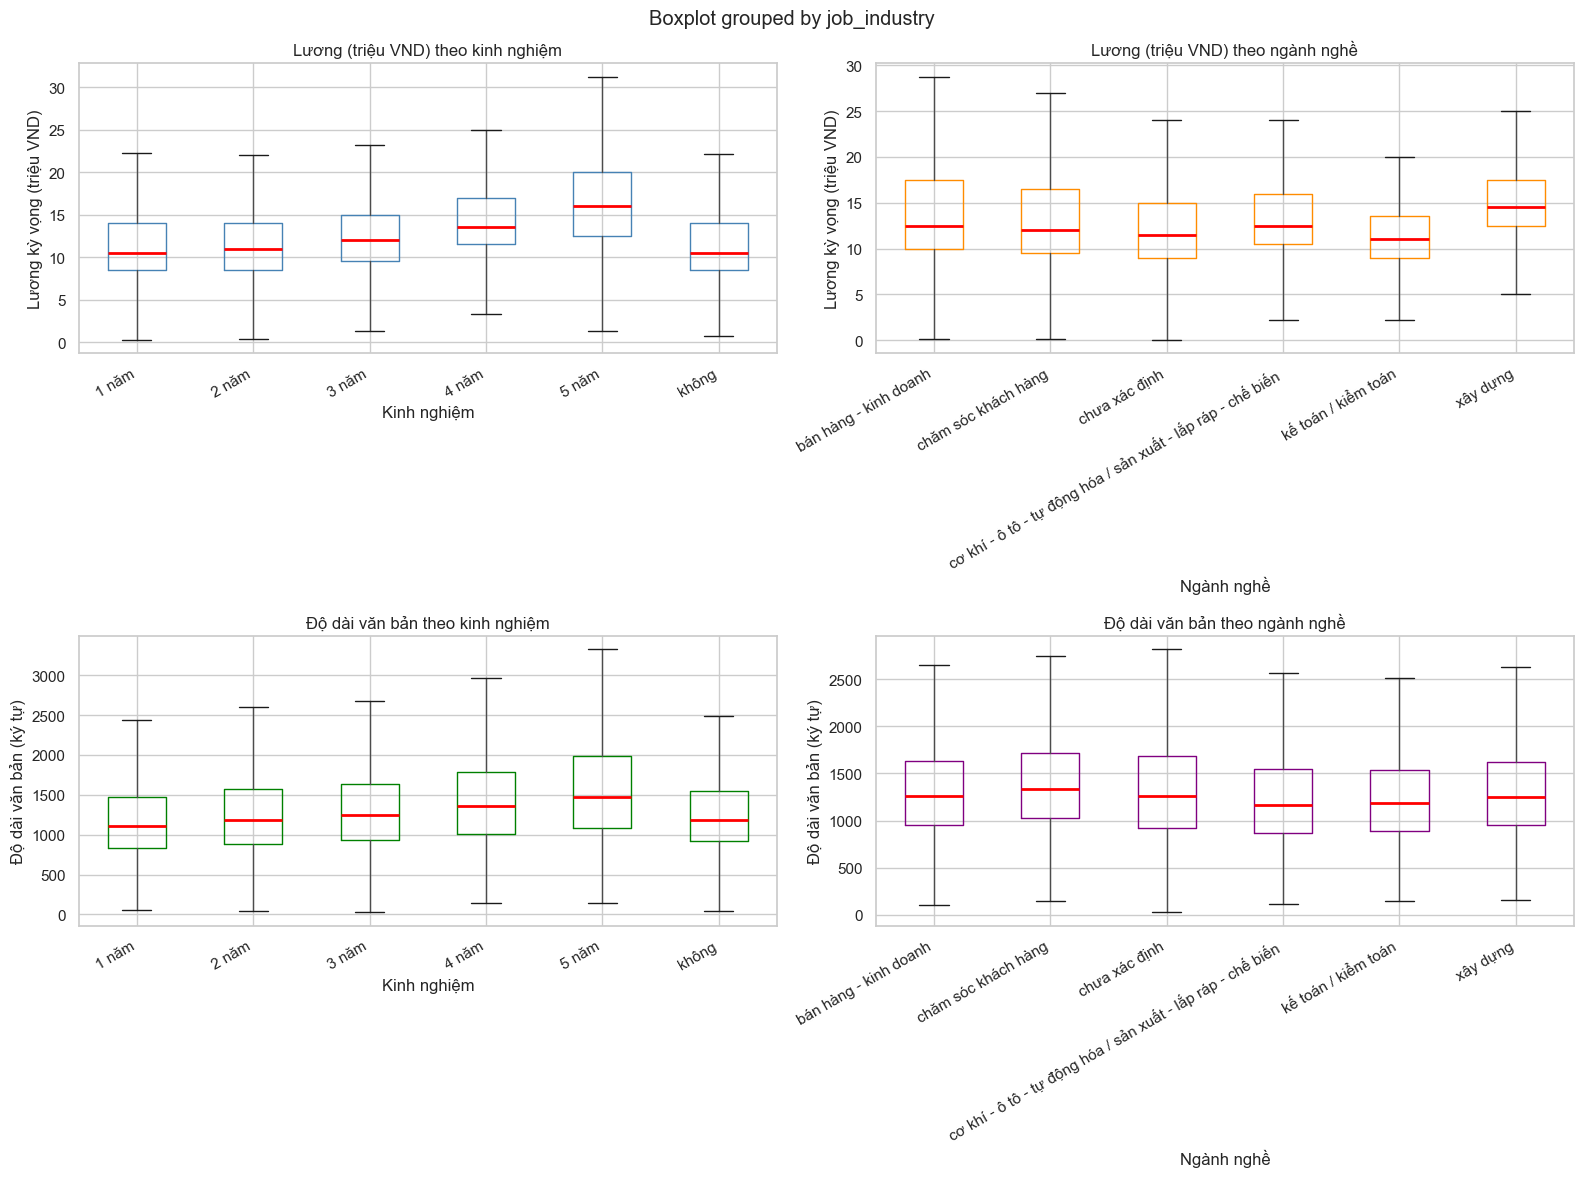

Đã lưu boxplot.


In [65]:
# === Boxplot: Phân phối salary và text_length theo nhóm ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Boxplot: Phân phối các biến quan trọng theo nhóm", fontsize=15, fontweight="bold")

# Top 6 nhóm kinh nghiệm theo số lượng
top_exp = train_df["experience_level"].value_counts().head(6).index.tolist()
top_ind = train_df["job_industry"].value_counts().head(6).index.tolist()
plot_df_exp = train_df[train_df["experience_level"].isin(top_exp)].copy()
plot_df_ind = train_df[train_df["job_industry"].isin(top_ind)].copy()

# 1. Salary by experience_level
ax = axes[0, 0]
plot_df_exp.boxplot(column="salary_expected_million_vnd", by="experience_level",
                    ax=ax, showfliers=False, grid=True,
                    boxprops=dict(color='steelblue'),
                    medianprops=dict(color='red', linewidth=2))
ax.set_title("Lương (triệu VND) theo kinh nghiệm")
ax.set_xlabel("Kinh nghiệm")
ax.set_ylabel("Lương kỳ vọng (triệu VND)")
plt.sca(ax); plt.xticks(rotation=30, ha='right')

# 2. Salary by job_industry
ax = axes[0, 1]
plot_df_ind.boxplot(column="salary_expected_million_vnd", by="job_industry",
                    ax=ax, showfliers=False, grid=True,
                    boxprops=dict(color='darkorange'),
                    medianprops=dict(color='red', linewidth=2))
ax.set_title("Lương (triệu VND) theo ngành nghề")
ax.set_xlabel("Ngành nghề")
ax.set_ylabel("Lương kỳ vọng (triệu VND)")
plt.sca(ax); plt.xticks(rotation=30, ha='right')

# 3. final_text_length by experience_level
ax = axes[1, 0]
plot_df_exp.boxplot(column="final_text_length", by="experience_level",
                    ax=ax, showfliers=False, grid=True,
                    boxprops=dict(color='green'),
                    medianprops=dict(color='red', linewidth=2))
ax.set_title("Độ dài văn bản theo kinh nghiệm")
ax.set_xlabel("Kinh nghiệm")
ax.set_ylabel("Độ dài văn bản (ký tự)")
plt.sca(ax); plt.xticks(rotation=30, ha='right')

# 4. final_text_length by job_industry
ax = axes[1, 1]
plot_df_ind.boxplot(column="final_text_length", by="job_industry",
                    ax=ax, showfliers=False, grid=True,
                    boxprops=dict(color='purple'),
                    medianprops=dict(color='red', linewidth=2))
ax.set_title("Độ dài văn bản theo ngành nghề")
ax.set_xlabel("Ngành nghề")
ax.set_ylabel("Độ dài văn bản (ký tự)")
plt.sca(ax); plt.xticks(rotation=30, ha='right')

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_plot(fig, "boxplot_salary_textlen_by_group.png")
plt.show()
print("Đã lưu boxplot.")


## 5. Distribution shift giữa train và test


,column,train_mean,test_mean,train_median,test_median,ks_statistic,ks_pvalue
0,salary_expected_million_vnd,13.706971,13.643455,12.000000,12.000000,0.001540,0.999604
1,log_salary_expected,2.582139,2.580540,2.564949,2.564949,0.001540,0.999604
2,salary_range_width,7.420316,7.348420,5.000000,5.000000,0.001570,0.999440
3,final_text_length,1350.802305,1348.129138,1237.000000,1238.000000,0.003133,0.675278


,column,value,train_ratio,test_ratio,abs_diff
12,experience_level,3 năm,0.296340,0.291563,0.004777
24,education_level,không,0.344024,0.339360,0.004663
27,education_level,đại học,0.152222,0.154737,0.002515
14,experience_level,2 năm,0.156365,0.158871,0.002506
48,job_industry,kế toán / kiểm toán,0.084542,0.083058,0.001484
53,job_industry,lao động phổ thông,0.039502,0.038272,0.001230
37,job_position,trưởng phòng,0.032216,0.033390,0.001174
16,experience_level,5 năm,0.063250,0.064331,0.001081
26,education_level,trung cấp,0.158011,0.159075,0.001064
34,job_position,nhân viên,0.798406,0.797363,0.001043


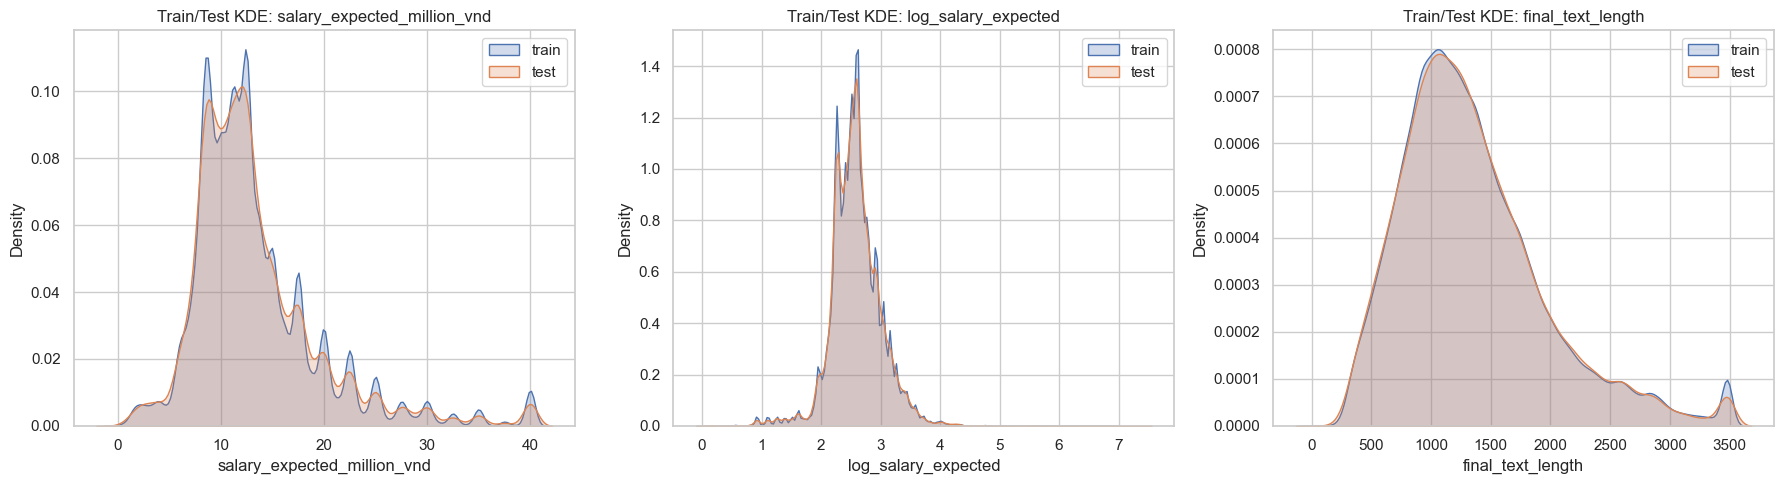

In [66]:
shift_numeric_rows = []
for column in ["salary_expected_million_vnd", "log_salary_expected", "salary_range_width", "final_text_length"]:
    train_values = train_df[column].dropna()
    test_values = test_df[column].dropna()
    ks = ks_2samp(train_values, test_values)
    shift_numeric_rows.append(
        {
            "column": column,
            "train_mean": float(train_values.mean()),
            "test_mean": float(test_values.mean()),
            "train_median": float(train_values.median()),
            "test_median": float(test_values.median()),
            "ks_statistic": float(ks.statistic),
            "ks_pvalue": float(ks.pvalue),
        }
    )

shift_numeric = pd.DataFrame(shift_numeric_rows)
shift_categorical = pd.concat(
    [top_category_shift(train_df, test_df, column) for column in ["job_type", "experience_level", "education_level", "job_position", "job_industry", "location_simplified"]],
    ignore_index=True,
)

display(shift_numeric)
display(shift_categorical.sort_values("abs_diff", ascending=False).head(30))

shift_numeric.to_csv(FEATURES_DIR / "distribution_shift_numeric.csv", index=False)
shift_categorical.to_csv(FEATURES_DIR / "distribution_shift_categorical.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, column, clip_quantile in zip(
    axes,
    ["salary_expected_million_vnd", "log_salary_expected", "final_text_length"],
    [0.99, None, 0.99],
):
    train_values = train_df[column].dropna()
    test_values = test_df[column].dropna()
    if clip_quantile is not None:
        upper = train_values.quantile(clip_quantile)
        train_values = train_values.clip(upper=upper)
        test_values = test_values.clip(upper=upper)
    sns.kdeplot(train_values, ax=ax, label="train", fill=True, alpha=0.25)
    sns.kdeplot(test_values, ax=ax, label="test", fill=True, alpha=0.25)
    ax.set_title(f"Train/Test KDE: {column}")
    ax.legend()
save_plot(fig, "shift_numeric_kde_overlay.png")


### 5.1. Kết luận về độ lệch phân phối

Dựa trên bảng KS test và bảng chênh lệch tỷ lệ categorical ở trên, nhóm đánh giá distribution shift theo quy tắc: `ks_pvalue > 0.05` hoặc `ks_statistic` nhỏ cho thấy phân phối numeric giữa train/test không lệch đáng kể; với categorical, `abs_diff` nhỏ cho thấy các nhóm phổ biến giữ tỷ lệ ổn định.


### 5.2. Biểu đồ so sánh train/test cho categorical và text


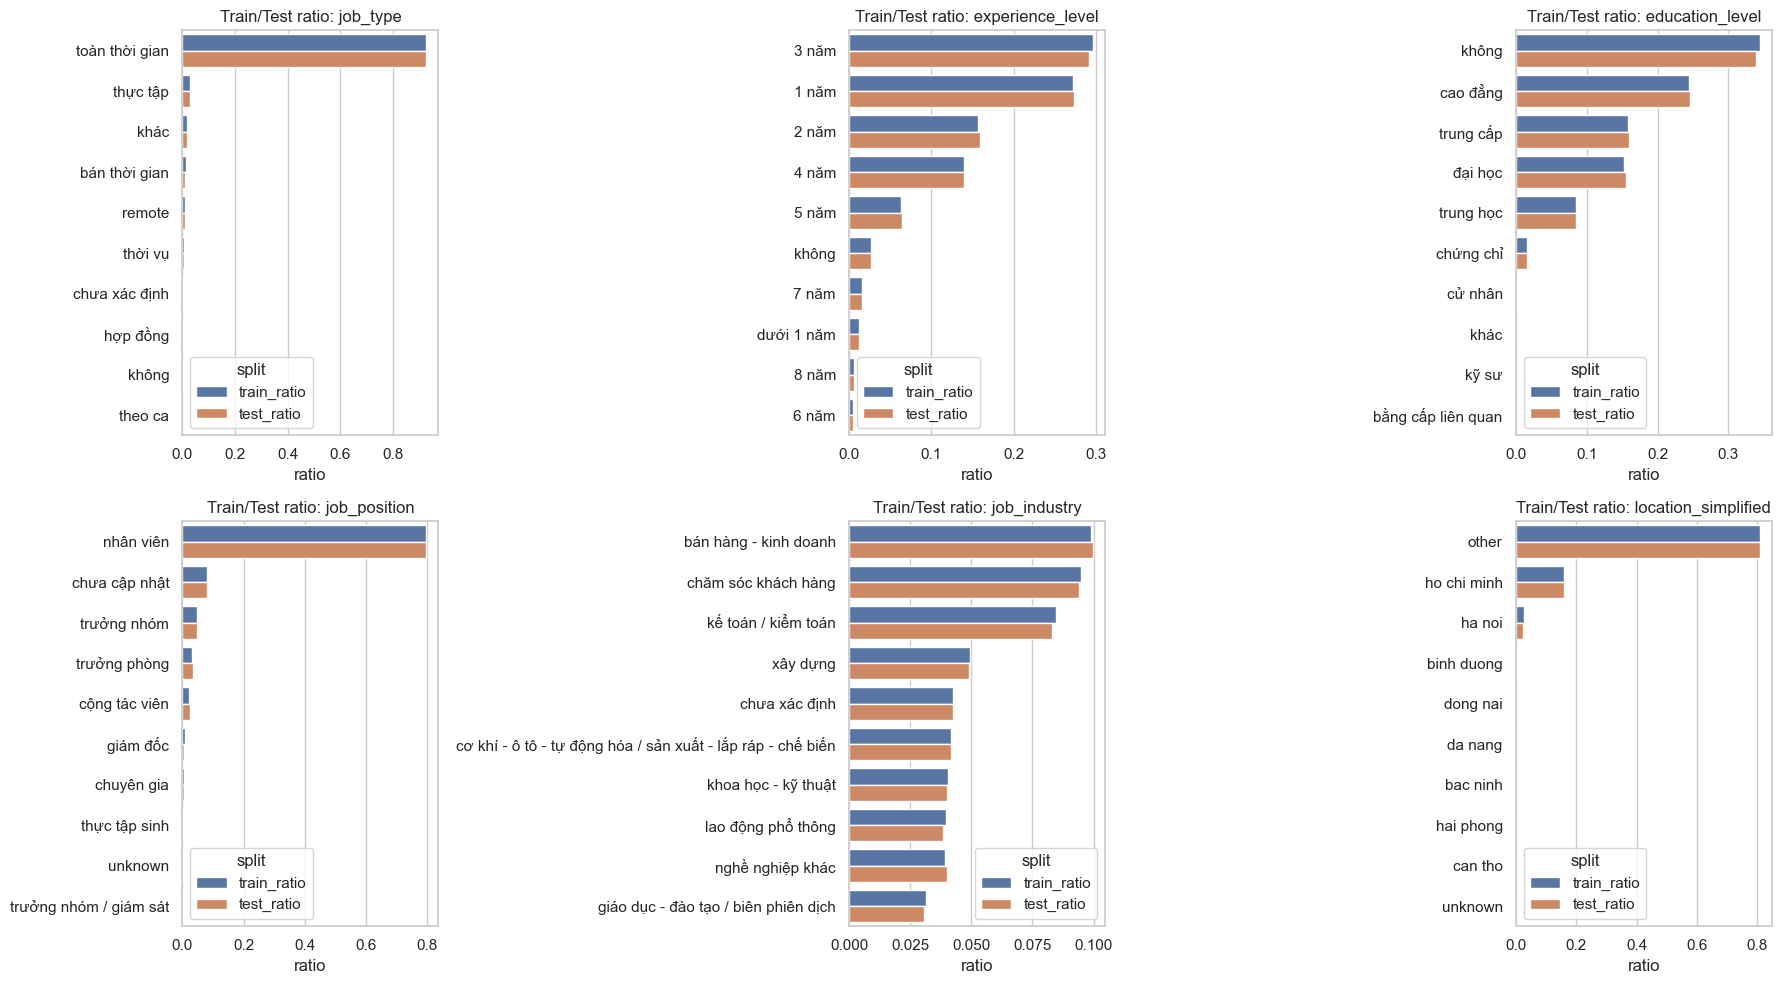

In [67]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, column in zip(axes.ravel(), ["job_type", "experience_level", "education_level", "job_position", "job_industry", "location_simplified"]):
    shift = top_category_shift(train_df, test_df, column, top_n=10)
    plot_df = shift.melt(id_vars=["column", "value"], value_vars=["train_ratio", "test_ratio"], var_name="split", value_name="ratio")
    sns.barplot(data=plot_df, x="ratio", y="value", hue="split", ax=ax)
    ax.set_title(f"Train/Test ratio: {column}")
    ax.set_xlabel("ratio")
    ax.set_ylabel("")
save_plot(fig, "shift_categorical_grouped_bars.png")



## 6. Lựa chọn và thiết kế đặc trưng

### 6.1. Bảng lựa chọn đặc trưng (Feature Selection Table)
Bảng dưới đây trình bày các nhóm cột quan trọng trong dữ liệu sạch, quyết định có đưa vào feature matrix clustering hay không, và lý do. Mục tiêu là clustering thuần NLP: học cụm từ nội dung tin tuyển dụng, còn metadata chỉ dùng để đánh giá/profile cụm sau khi có kết quả.

| Cột / nhóm cột | Kiểu dữ liệu | Đưa vào feature matrix? | Vai trò | Lý do |
|---|---|---:|---|---|
| `job_title` | Text | Có | Text feature | Tiêu đề ngắn, giàu ngữ nghĩa; được lặp 2 lần để tăng trọng số nhẹ cho tín hiệu chức danh. |
| `job_description` | Text | Có | Text feature | Mô tả nhiệm vụ và ngữ cảnh công việc, là nguồn tín hiệu NLP chính. |
| `requirements` | Text | Có | Text feature | Chứa kỹ năng, công cụ, bằng cấp và kinh nghiệm yêu cầu, rất hữu ích để tách nhóm nghề. |
| `benefits` | Text | Có | Text feature | Là nội dung thật của JD; giúp bổ sung tín hiệu về chế độ, môi trường và loại hình công việc. |
| `job_industry` | Categorical | Không | Metadata validation/profile | Đây là nhãn ngành có sẵn. Nếu đưa vào input sẽ gây leakage/circular reasoning: model gom cụm theo nhãn thay vì tự học từ text. |
| `experience_level` | Categorical | Không | Metadata profile | Không đưa vào feature engineering chính để giữ pipeline thuần NLP; dùng sau này để mô tả cụm theo mức kinh nghiệm. |
| `education_level` | Categorical | Không | Metadata profile | Dùng để giải thích cụm, không dùng làm tín hiệu train trong notebook này. |
| `job_type` | Categorical | Không | Metadata profile | Dùng để profile cụm, tránh ép cụm theo hình thức làm việc có sẵn. |
| `job_position` | Categorical | Không | Metadata profile | Dùng để đối chiếu sau clustering, không đưa vào input để tránh metadata chi phối cụm. |
| `location_simplified` / `location` | Categorical | Không | Metadata profile | Địa lý hữu ích để mô tả cụm nhưng không phải nội dung NLP cốt lõi của bài toán hiện tại. |
| `salary_expected_million_vnd`, `salary_min`, `salary_max`, `salary_range_width`, `is_salary_outlier` | Numeric | Không | EDA/profile | Salary có outlier và thang đo riêng; nếu đưa vào có thể làm cụm bị chi phối bởi lương thay vì ngữ nghĩa JD. |
| `job_description_length`, `requirements_length`, `benefits_length`, `final_text_length` | Numeric | Không | EDA/quality check | Độ dài văn bản giúp kiểm tra chất lượng và shift, nhưng không phải đặc trưng ngữ nghĩa. |

### 6.2. Lý do chọn pipeline TF-IDF -> SVD -> UMAP

| Bước | Phương pháp | Lý do lựa chọn |
|---|---|---|
| Biểu diễn văn bản | TF-IDF `ngram_range=(1, 3)` | Kết hợp từ đơn và cụm từ chuyên ngành; `sublinear_tf=True` giảm ảnh hưởng của văn bản quá dài. |
| Lọc nhiễu | `max_df=0.40`, `min_df=20`, tokenized Vietnamese stopwords | Loại từ quá phổ biến, từ quá hiếm/lỗi chính tả và từ dừng phổ biến. |
| Giảm chiều bước 1 | TruncatedSVD 300 chiều | Nén ma trận TF-IDF thưa 30.000 cột thành ma trận dense để UMAP xử lý ổn định hơn. |
| Giảm nhiễu template | Bỏ SVD component đầu tiên trước UMAP | Component đầu có thể chứa wording/template chung của JD; bỏ ra giúp UMAP tập trung hơn vào cấu trúc ngữ nghĩa. |
| Giảm chiều bước 2 | UMAP 10 chiều | Tạo embedding gọn để bàn giao cho người làm clustering. |
| Visualization | UMAP 2D và t-SNE 2D riêng | 2D chỉ để kiểm tra trực quan và external validation, không thay thế embedding 10D cho clustering. |


In [68]:
tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 3),
    stop_words=TOKENIZED_VIETNAMESE_STOPWORDS,
    min_df=20,
    max_df=0.40,
    sublinear_tf=True,
)

X_train_text = tfidf.fit_transform(train_df["final_text"])
X_test_text = tfidf.transform(test_df["final_text"])

X_train_features = X_train_text
X_test_features = X_test_text
feature_normalizer = None

leakage_columns = set(CATEGORICAL_METADATA_COLUMNS + BASE_NUMERIC_COLUMNS + TEXT_LENGTH_COLUMNS)
assert leakage_columns.isdisjoint(TEXT_COLUMNS_FOR_CLUSTERING), "Metadata/numeric columns leaked into clustering text columns."
assert sparse.issparse(X_train_features), "TF-IDF feature matrix must stay sparse."

print("TF-IDF features:", X_train_text.shape[1])
print("Text columns for clustering:", TEXT_COLUMNS_FOR_CLUSTERING)
print("Các cột metadata không đưa vào feature matrix:", CATEGORICAL_METADATA_COLUMNS + BASE_NUMERIC_COLUMNS + TEXT_LENGTH_COLUMNS)
print("Số numeric feature dùng cho clustering:", len(NUMERIC_COLUMNS))
print("Final sparse feature shape:", X_train_features.shape, X_test_features.shape)


TF-IDF features: 30000
Text columns for clustering: ['job_title', 'job_description', 'requirements', 'benefits']
Các cột metadata không đưa vào feature matrix: ['job_type', 'job_industry', 'experience_level', 'education_level', 'job_position', 'location_simplified', 'salary_expected_million_vnd', 'salary_range_width', 'salary_min', 'salary_max', 'is_salary_outlier', 'job_description_length', 'requirements_length', 'benefits_length', 'final_text_length']
Số numeric feature dùng cho clustering: 0
Final sparse feature shape: (529109, 30000) (58790, 30000)


### 6.3. Kiểm tra feature matrix và leakage
Cell này kiểm tra `X_train_features` là sparse TF-IDF thuần text. Metadata như `job_industry`, `experience_level`, salary, location và text length chỉ được dùng cho EDA/profile, không được đưa vào SVD/UMAP.


In [69]:
print("X_train_features type:", type(X_train_features))
print("X_train_features shape:", X_train_features.shape)
print("X_train_features nnz:", X_train_features.nnz)
print("Density:", X_train_features.nnz / (X_train_features.shape[0] * X_train_features.shape[1]))
print("Block shapes:", {
    "text_tfidf_only": X_train_text.shape,
    "numeric_used_for_clustering": len(NUMERIC_COLUMNS),
})
print("Metadata loại khỏi clustering:", CATEGORICAL_METADATA_COLUMNS + BASE_NUMERIC_COLUMNS + TEXT_LENGTH_COLUMNS)

assert X_train_features is X_train_text, "Final sparse features must be the text-only TF-IDF matrix."
assert sparse.issparse(X_train_features), "X_train_features must be the sparse TF-IDF matrix."
assert X_train_features.shape[1] == X_train_text.shape[1], "Feature matrix must not include OHE/numeric columns."
assert X_train_features.shape[1] > 1000, "Feature matrix has too few columns; check TF-IDF assembly."
assert X_train_features.nnz > X_train_features.shape[0], "Feature matrix is unexpectedly empty/sparse."
assert len(NUMERIC_COLUMNS) == 0, "Numeric columns must stay out of the clustering feature matrix."
assert "job_industry" not in TEXT_COLUMNS_FOR_CLUSTERING
assert "experience_level" not in TEXT_COLUMNS_FOR_CLUSTERING


X_train_features type: <class 'scipy.sparse._csr.csr_matrix'>
X_train_features shape: (529109, 30000)
X_train_features nnz: 192037465
Density: 0.01209816660335268
Block shapes: {'text_tfidf_only': (529109, 30000), 'numeric_used_for_clustering': 0}
Metadata loại khỏi clustering: ['job_type', 'job_industry', 'experience_level', 'education_level', 'job_position', 'location_simplified', 'salary_expected_million_vnd', 'salary_range_width', 'salary_min', 'salary_max', 'is_salary_outlier', 'job_description_length', 'requirements_length', 'benefits_length', 'final_text_length']


## 7. Dimensionality Reduction Pipeline (TF-IDF -> SVD -> UMAP)
Pipeline chỉ nén ma trận TF-IDF thuần text. SVD giảm sparse TF-IDF xuống 300 chiều, bỏ component đầu tiên trước UMAP để giảm nhiễu template/common wording, rồi UMAP giảm xuống 10 chiều để bàn giao cho bước clustering.


In [73]:
# 1. SVD bridge: reduce sparse text-only TF-IDF to 300 dimensions
max_svd_components = min(MAX_SVD_COMPONENTS, X_train_features.shape[1] - 1, X_train_features.shape[0] - 1)
svd = TruncatedSVD(n_components=max_svd_components, random_state=RANDOM_STATE)
X_train_svd = svd.fit_transform(X_train_features)
X_test_svd = svd.transform(X_test_features)

explained_variance = svd.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()
svd_variance_df = pd.DataFrame({
    "component": np.arange(1, len(explained_variance) + 1),
    "explained_variance_ratio": explained_variance,
    "cumulative_explained_variance": cumulative_variance,
})
svd_variance_df.to_csv(FEATURES_DIR / "svd_explained_variance_text_only.csv", index=False)

print("SVD shape:", X_train_svd.shape)
print("Top SVD explained variance:")
display(svd_variance_df.head(10))

if DROP_FIRST_SVD_COMPONENT_FOR_UMAP and X_train_svd.shape[1] > 1:
    X_train_svd_for_umap = X_train_svd[:, 1:]
    X_test_svd_for_umap = X_test_svd[:, 1:]
    dropped_svd_components = 1
else:
    X_train_svd_for_umap = X_train_svd
    X_test_svd_for_umap = X_test_svd
    dropped_svd_components = 0

print("SVD shape used for UMAP:", X_train_svd_for_umap.shape)
print("Số SVD component đầu bị bỏ trước UMAP:", dropped_svd_components)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(svd_variance_df["component"], svd_variance_df["cumulative_explained_variance"], color="#4c78a8")
ax.axvline(dropped_svd_components + 1, color="#e45756", linestyle="--", linewidth=1, label="UMAP starts after dropped component(s)")
ax.set_title("SVD cumulative explained variance - text-only TF-IDF")
ax.set_xlabel("SVD component")
ax.set_ylabel("cumulative explained variance")
ax.legend()
save_plot(fig, "svd_cumulative_explained_variance_text_only.png")

# 2. UMAP: reduce text-only SVD features to 10 clustering dimensions

# Windows sandbox note: pynndescent builds RP-tree leaf arrays with joblib
# threads by default. Use the same algorithm with serial leaf extraction so
# UMAP can run in restricted environments that block multiprocessing pipes.
import pynndescent.rp_trees as _pynndescent_rp_trees

def _rptree_leaf_array_serial(rp_forest):
    max_leaf_size = np.max([rp_tree.leaf_size for rp_tree in rp_forest])
    return [
        _pynndescent_rp_trees.get_leaves_from_tree(rp_tree, max_leaf_size)
        for rp_tree in rp_forest
    ]

_pynndescent_rp_trees.rptree_leaf_array_parallel = _rptree_leaf_array_serial

print("Running UMAP...")
reducer = umap.UMAP(
    n_components=10,
    n_neighbors=30,
    min_dist=0.1,
    metric="cosine",
    random_state=RANDOM_STATE,
    n_jobs=1,
    angular_rp_forest=False,
)
X_train_umap = reducer.fit_transform(X_train_svd_for_umap)
X_test_umap = reducer.transform(X_test_svd_for_umap)

print("UMAP shape:", X_train_umap.shape)


MemoryError: Unable to allocate 1.22 GiB for an array with shape (529109, 310) and data type float64

Exception ignored in: 'scipy.linalg._decomp_lu_cython.lu_decompose'
Traceback (most recent call last):
  File "d:\02. DUT\04. Khoa học dữ liệu\final-data-science\.venv\Lib\site-packages\scipy\linalg\_decomp_lu.py", line 363, in lu
    lu_dispatcher(a1, u, p, permute_l)
numpy._core._exceptions._ArrayMemoryError: Unable to allocate 1.22 GiB for an array with shape (529109, 310) and data type float64


KeyboardInterrupt: 

Visualization sample: (20000, 299)
Running sampled 2D UMAP for visualization...
Running sampled t-SNE for visualization...


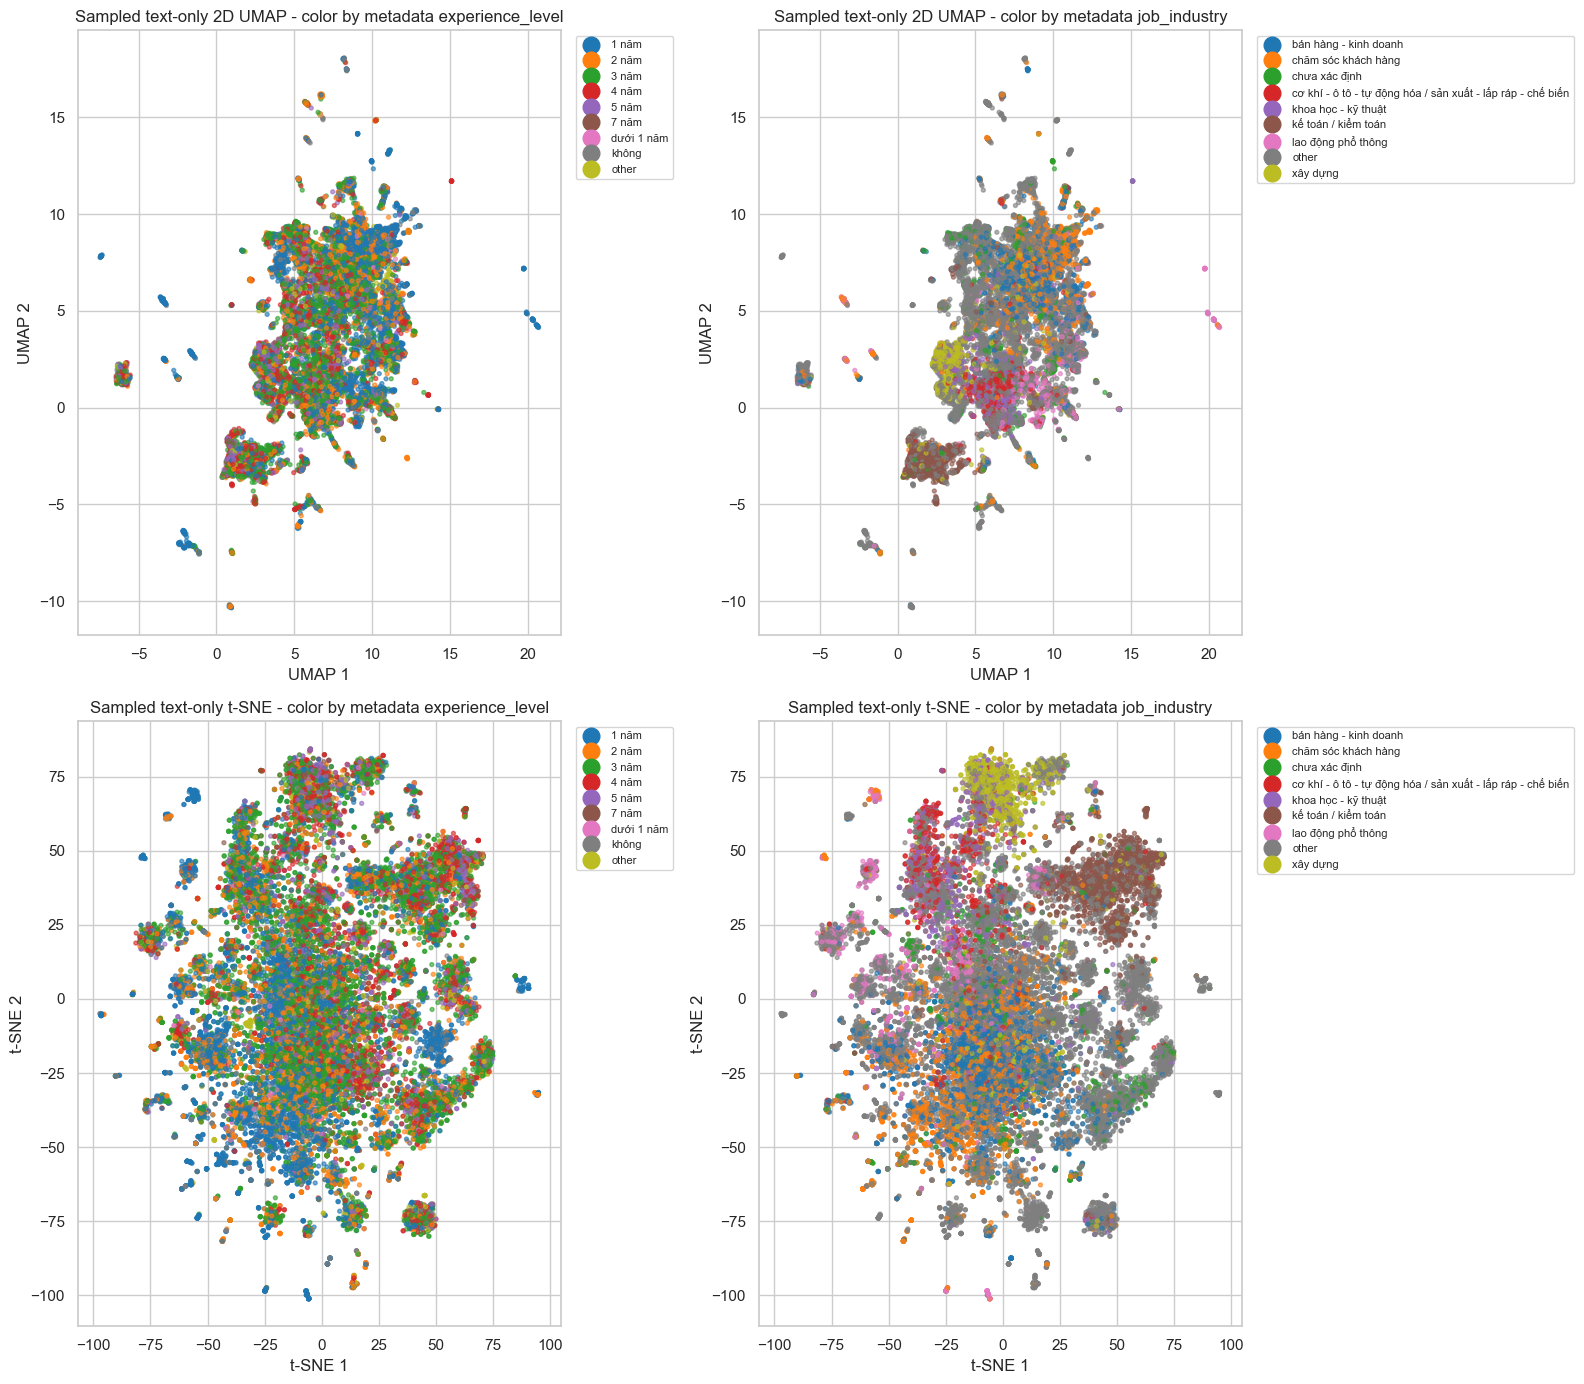

In [74]:
# --- 2D visualization on representative sample only ---
VIS_SAMPLE_SIZE = 20000
rng = np.random.default_rng(RANDOM_STATE)

sample_n = min(VIS_SAMPLE_SIZE, X_train_svd_for_umap.shape[0])
sample_idx = rng.choice(X_train_svd_for_umap.shape[0], size=sample_n, replace=False)

X_vis_svd = X_train_svd_for_umap[sample_idx]
vis_meta = train_df.iloc[sample_idx].copy()

print("Visualization sample:", X_vis_svd.shape)

print("Running sampled 2D UMAP for visualization...")
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.3,
    metric="cosine",
    random_state=RANDOM_STATE,
    n_jobs=1,
    angular_rp_forest=False,
)
X_train_umap_2d_sample = reducer_2d.fit_transform(X_vis_svd)

print("Running sampled t-SNE for visualization...")
tsne = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    perplexity=30,
    init="pca",
    learning_rate="auto",
)
X_train_tsne_sample = tsne.fit_transform(X_vis_svd)

def compact_labels(series, top_n=8):
    labels = series.fillna("unknown").astype(str)
    top_values = labels.value_counts().head(top_n).index
    return labels.where(labels.isin(top_values), "other")

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# UMAP/t-SNE colors are metadata-only external validation, not clustering input.
for ax, column in zip(axes[0], ["experience_level", "job_industry"]):
    labels = compact_labels(vis_meta[column], top_n=8)
    unique_labels = sorted(labels.unique())
    palette = dict(zip(unique_labels, sns.color_palette("tab10", n_colors=len(unique_labels))))
    colors = labels.map(palette)

    ax.scatter(
        X_train_umap_2d_sample[:, 0],
        X_train_umap_2d_sample[:, 1],
        c=list(colors),
        s=8,
        alpha=0.6,
    )
    ax.set_title(f"Sampled text-only 2D UMAP - color by metadata {column}")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

    handles = [
        plt.Line2D([0], [0], marker="o", color=color, label=label, linestyle="None")
        for label, color in palette.items()
    ]
    ax.legend(handles=handles, fontsize=8, markerscale=2, bbox_to_anchor=(1.02, 1), loc="upper left")

for ax, column in zip(axes[1], ["experience_level", "job_industry"]):
    labels = compact_labels(vis_meta[column], top_n=8)
    unique_labels = sorted(labels.unique())
    palette = dict(zip(unique_labels, sns.color_palette("tab10", n_colors=len(unique_labels))))
    colors = labels.map(palette)

    ax.scatter(
        X_train_tsne_sample[:, 0],
        X_train_tsne_sample[:, 1],
        c=list(colors),
        s=8,
        alpha=0.6,
    )
    ax.set_title(f"Sampled text-only t-SNE - color by metadata {column}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

    handles = [
        plt.Line2D([0], [0], marker="o", color=color, label=label, linestyle="None")
        for label, color in palette.items()
    ]
    ax.legend(handles=handles, fontsize=8, markerscale=2, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
save_plot(fig, "dim_reduction_metadata_profile_text_only_sampled_20k.png")
plt.show()

Biểu đồ UMAP/t-SNE 2D được vẽ trên mẫu ngẫu nhiên 20.000 điểm để phục vụ trực quan hóa. Embedding 10 chiều dùng cho clustering vẫn được tạo trên toàn bộ tập train/test.

### Nhận xét SVD/UMAP text-only
- **Feature matrix đã sửa leakage**: `X_train_features` chỉ gồm TF-IDF từ `job_title`, `job_description`, `requirements`, `benefits`; `job_industry`, `experience_level`, salary và location chỉ là metadata.
- **SVD**: 300 component được fit trên TF-IDF thuần text. Component đầu tiên có thể chứa common wording/template nên được cắt bỏ trước UMAP theo cấu hình `DROP_FIRST_SVD_COMPONENT_FOR_UMAP`.
- **UMAP/t-SNE**: Màu theo `job_industry` và `experience_level` chỉ là external validation/profiling. Nếu vẫn xuất hiện vùng ngành nghề tương đối rõ, đó mới là tín hiệu ngữ nghĩa học từ text, không phải do OHE nhãn ngành.


## 8. Export artifacts cho clustering


In [ ]:
if SAMPLE_SIZE is not None:
    print(f"CẢNH BÁO: Artifact đang được export từ SAMPLE_SIZE={SAMPLE_SIZE}, chưa phải toàn bộ dataset.")
    print("Đặt SAMPLE_SIZE = None và chạy lại toàn bộ notebook trước khi nộp cuối cùng.")

sparse.save_npz(FEATURES_DIR / "X_train_features.npz", X_train_features)
sparse.save_npz(FEATURES_DIR / "X_test_features.npz", X_test_features)
np.save(FEATURES_DIR / "X_train_svd.npy", X_train_svd)
np.save(FEATURES_DIR / "X_test_svd.npy", X_test_svd)
np.save(FEATURES_DIR / "X_train_umap.npy", X_train_umap)
np.save(FEATURES_DIR / "X_test_umap.npy", X_test_umap)

train_metadata = train_df[[column for column in METADATA_COLUMNS if column in train_df.columns]].copy()
test_metadata = test_df[[column for column in METADATA_COLUMNS if column in test_df.columns]].copy()
train_metadata.to_csv(FEATURES_DIR / "train_metadata.csv", index=False)
test_metadata.to_csv(FEATURES_DIR / "test_metadata.csv", index=False)

feature_pipeline = {
    "tfidf": tfidf,
    "svd": svd,
    "umap": reducer,
    "feature_normalizer": feature_normalizer,
    "text_columns_for_clustering": TEXT_COLUMNS_FOR_CLUSTERING,
    "metadata_columns": METADATA_COLUMNS,
    "categorical_metadata_columns": CATEGORICAL_METADATA_COLUMNS,
    "numeric_columns_used_for_clustering": NUMERIC_COLUMNS,
    "tfidf_max_features": TFIDF_MAX_FEATURES,
    "max_svd_components": max_svd_components,
    "drop_first_svd_component_for_umap": DROP_FIRST_SVD_COMPONENT_FOR_UMAP,
    "dropped_svd_components": dropped_svd_components,
    "svd_components_used_for_umap": X_train_svd_for_umap.shape[1],
    "umap_components": 10,
    "random_state": RANDOM_STATE,
}
joblib.dump(tfidf, FEATURES_DIR / "tfidf_model.joblib")
joblib.dump(svd, FEATURES_DIR / "svd_model.joblib")
joblib.dump(reducer, FEATURES_DIR / "umap_model.joblib")
joblib.dump(feature_pipeline, FEATURES_DIR / "feature_pipeline.joblib")

summary = pd.DataFrame(
    [
        {"metric": "train_rows", "value": X_train_features.shape[0]},
        {"metric": "test_rows", "value": X_test_features.shape[0]},
        {"metric": "tfidf_features", "value": X_train_text.shape[1]},
        {"metric": "total_sparse_features", "value": X_train_features.shape[1]},
        {"metric": "numeric_features_used_for_clustering", "value": len(NUMERIC_COLUMNS)},
        {"metric": "metadata_features_used_for_clustering", "value": 0},
        {"metric": "max_svd_components", "value": max_svd_components},
        {"metric": "dropped_svd_components_before_umap", "value": dropped_svd_components},
        {"metric": "svd_components_used_for_umap", "value": X_train_svd_for_umap.shape[1]},
        {"metric": "umap_components", "value": 10},
        {"metric": "salary_outlier_ratio_train", "value": float(train_df["is_salary_outlier"].mean())},
        {"metric": "salary_outlier_ratio_test", "value": float(test_df["is_salary_outlier"].mean())},
    ]
)
summary.to_csv(FEATURES_DIR / "feature_engineering_summary.csv", index=False)

display(summary)
print("Đã lưu artifact feature text-only vào", FEATURES_DIR)


CẢNH BÁO: Artifact đang được export từ SAMPLE_SIZE=20000, chưa phải toàn bộ dataset.
Đặt SAMPLE_SIZE = None và chạy lại toàn bộ notebook trước khi nộp cuối cùng.


,metric,value
0,train_rows,20000.00000
1,test_rows,2000.00000
2,tfidf_features,30000.00000
3,total_sparse_features,30000.00000
4,numeric_features_used_for_clustering,0.00000
5,metadata_features_used_for_clustering,0.00000
6,max_svd_components,300.00000
7,dropped_svd_components_before_umap,1.00000
8,svd_components_used_for_umap,299.00000
9,umap_components,10.00000


Đã lưu artifact feature text-only vào d:\02. DUT\04. Khoa học dữ liệu\final-data-science\artifacts\features


## 9. Validate output và kiểm tra readiness của feature engineering
Cell này chỉ kiểm tra artifact, shape và leakage của feature engineering. Notebook 03 không tính metrics clustering và không fit thuật toán clustering chính thức; phần đó được bàn giao cho notebook/modeling tiếp theo.


In [ ]:
expected_files = [
    FEATURES_DIR / "X_train_features.npz",
    FEATURES_DIR / "X_test_features.npz",
    FEATURES_DIR / "X_train_svd.npy",
    FEATURES_DIR / "X_test_svd.npy",
    FEATURES_DIR / "X_train_umap.npy",
    FEATURES_DIR / "X_test_umap.npy",
    FEATURES_DIR / "train_metadata.csv",
    FEATURES_DIR / "test_metadata.csv",
    FEATURES_DIR / "feature_engineering_summary.csv",
    FEATURES_DIR / "tfidf_model.joblib",
    FEATURES_DIR / "svd_model.joblib",
    FEATURES_DIR / "umap_model.joblib",
    FEATURES_DIR / "feature_pipeline.joblib",
]
for path in expected_files:
    assert path.exists(), f"Missing output file: {path}"

loaded_train_features = sparse.load_npz(FEATURES_DIR / "X_train_features.npz")
loaded_test_features = sparse.load_npz(FEATURES_DIR / "X_test_features.npz")
loaded_train_svd = np.load(FEATURES_DIR / "X_train_svd.npy")
loaded_test_svd = np.load(FEATURES_DIR / "X_test_svd.npy")
loaded_train_umap = np.load(FEATURES_DIR / "X_train_umap.npy")
loaded_test_umap = np.load(FEATURES_DIR / "X_test_umap.npy")
loaded_train_metadata = pd.read_csv(FEATURES_DIR / "train_metadata.csv", nrows=5)
loaded_pipeline = joblib.load(FEATURES_DIR / "feature_pipeline.joblib")

assert loaded_train_features.shape[0] == len(train_df)
assert loaded_test_features.shape[0] == len(test_df)
assert loaded_train_features.shape[1] == X_train_text.shape[1]
assert loaded_test_features.shape[1] == X_test_text.shape[1]
assert loaded_train_svd.shape[0] == len(train_df)
assert loaded_test_svd.shape[0] == len(test_df)
assert loaded_train_umap.shape[0] == len(train_df)
assert loaded_test_umap.shape[0] == len(test_df)
assert loaded_train_umap.shape[1] == 10
assert loaded_test_umap.shape[1] == 10
assert np.isfinite(loaded_train_umap).all()
assert np.isfinite(loaded_test_umap).all()
assert "encoder" not in loaded_pipeline
assert "ohe_weight" not in loaded_pipeline
assert "categorical_columns" not in loaded_pipeline
assert "job_industry" not in loaded_pipeline["text_columns_for_clustering"]
assert "experience_level" not in loaded_pipeline["text_columns_for_clustering"]

print("Tất cả artifact feature engineering text-only đều hợp lệ.")
print("Loaded sparse shapes:", loaded_train_features.shape, loaded_test_features.shape)
print("Loaded SVD shapes:", loaded_train_svd.shape, loaded_test_svd.shape)
print("Loaded UMAP shapes:", loaded_train_umap.shape, loaded_test_umap.shape)
display(loaded_train_metadata)


Tất cả artifact feature engineering text-only đều hợp lệ.
Loaded sparse shapes: (20000, 30000) (2000, 30000)
Loaded SVD shapes: (20000, 300) (2000, 300)
Loaded UMAP shapes: (20000, 10) (2000, 10)


,id,job_title,company_name,location,location_simplified,job_industry,job_type,experience_level,education_level,job_position,salary_expected_million_vnd,salary_range_width,salary_min,salary_max,is_salary_outlier,final_text
0,435920,nhân viên kế toán (biết tiếng trung),công ty tnhh thương mại dịch vụ điện tử harbeth,"a6/7q,ql 1a , phường tân tạo a | a6/7q quốc lộ 1a, phường tân tạo a, quận bình tân, th...",other,kế toán / kiểm toán,toàn thời gian,3 năm,cao đẳng,nhân viên,13.5,3.0,12.0,15.0,0,nhân viên kế toán (biết tiếng trung) nhân viên kế toán (biết tiếng trung) kiểm kê hàng...
1,300501,nhân viên kinh doanh linh kiện máy tính - tại quận 10 (đi làm ngay),công ty tnhh kỹ thuật starfish vn,"666/46/7 đường 3/2, phường 14 | b6 ngõ 109 trường chinh, phường phương liệt | 666/46/7...",other,bán hàng - kinh doanh,toàn thời gian,4 năm,trung cấp,nhân viên,16.5,17.0,8.0,25.0,0,nhân viên kinh doanh linh kiện máy tính - tại quận 10 (đi làm ngay) nhân viên kinh doa...
2,425143,nhân viên phát triển thị trường khu vực bình tân,công ty cổ phần công nghệ sen đỏ,"tầng 5, toà nhà a, vườn ươm doanh nghiệp, lô d.01, đường tân thuận, phường tân thuận, ...",other,bán hàng - kinh doanh,toàn thời gian,1 năm,trung cấp,nhân viên,12.5,5.0,10.0,15.0,0,nhân viên phát triển thị trường khu vực bình tân nhân viên phát triển thị trường khu v...
3,379186,kế toán tổng hợp,công ty tnhh đồng nhân cargo,"172/97 an dương vương, phường 16 | 42 đường số 17 phường 10 quận 6 tphcm",ho chi minh,kế toán / kiểm toán,toàn thời gian,5 năm,không,nhân viên,14.5,1.0,14.0,15.0,0,"kế toán tổng hợp kế toán tổng hợp nhập và kiểm tra hóa đơn mua vào, bán ra cân đối mua..."
4,103669,nhân viên kinh doanh nội thất,công ty tnhh tm dv nội thất nda,"189/2 bạch đằng , phường 3, quận gò vấp, thành phố hồ chí minh, việt nam",other,bán hàng - kinh doanh,toàn thời gian,2 năm,trung cấp,chưa cập nhật,8.5,3.0,7.0,10.0,0,nhân viên kinh doanh nội thất nhân viên kinh doanh nội thất chào bán các mặt hàng của ...
